In [17]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from sklearn.model_selection import train_test_split
import copy
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [18]:
IMAGES_DIR = "/home/Joshua/Downloads/leopard_toad_identification/dataset/detect_2/dataset_clahe/images"
LABELS_DIR = "/home/Joshua/Downloads/leopard_toad_identification/dataset/detect_2/dataset_clahe/labels"
BATCH_SIZE = 16
EPOCHS = 50
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0001

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [19]:
# BLOCK 2: AUGMENTATION PIPELINES
def get_train_transform():
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.OneOf(
                [
                    A.MotionBlur(blur_limit=5, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                ],
                p=0.3,
            ),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            A.ToFloat(max_value=255.0),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
    )


def get_val_transform():
    return A.Compose(
        [A.ToFloat(max_value=255.0), ToTensorV2()],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
    )

In [21]:
# BLOCK 3: DATASET AND DATALOADERS
class WLTDataset(Dataset):
    def __init__(self, image_files, images_dir, labels_dir, transforms=None):
        self.image_files = image_files
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                for line in f.readlines():
                    class_id, x_center, y_center, width, height = map(
                        float, line.strip().split()
                    )

                    xmin = (x_center - width / 2) * w
                    ymin = (y_center - height / 2) * h
                    xmax = (x_center + width / 2) * w
                    ymax = (y_center + height / 2) * h

                    xmin, ymin = max(0.0, xmin), max(0.0, ymin)
                    xmax, ymax = min(float(w - 1.0), xmax), min(float(h - 1.0), ymax)

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(int(class_id) + 1)  # Shift for Background = 0

        if self.transforms is not None:
            transformed = self.transforms(
                image=image, bboxes=boxes, class_labels=labels
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["class_labels"]

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


all_images = [
    f for f in os.listdir(IMAGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))
]
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

train_dataset = WLTDataset(
    train_imgs, IMAGES_DIR, LABELS_DIR, transforms=get_train_transform()
)
val_dataset = WLTDataset(
    val_imgs, IMAGES_DIR, LABELS_DIR, transforms=get_val_transform()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

/tmp/ipykernel_399440/2947852116.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [22]:
# BLOCK 4: RETINANET MODEL SETUP
def get_retinanet_model(num_classes):
    model = torchvision.models.detection.retinanet_resnet50_fpn_v2(weights="DEFAULT")

    # 2. Extract necessary dimensions from the pre-trained model
    num_anchors = model.head.classification_head.num_anchors
    in_features = model.backbone.out_channels  # Usually 256 for FPN

    # 3. Replace the classification head to match our classes (Background + 3)
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_features, num_anchors=num_anchors, num_classes=num_classes
    )

    return model


# Number of classes = 4 (Background=0, WLT=1, Other_Frog=2, Mammal=3)
NUM_CLASSES = 4
model = get_retinanet_model(NUM_CLASSES)
model.to(DEVICE)

# Optimizer & Scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [23]:
# BLOCK 5: TRAINING LOOP
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

os.makedirs(
    "/home/Joshua/Downloads/leopard_toad_identification/detection/weights",
    exist_ok=True,
)
print("Starting RetinaNet Training (with Focal Loss)...")

for epoch in range(EPOCHS):
    # ==============================
    # 1. TRAINING PHASE
    # ==============================
    model.train()
    train_loss_accum = 0.0

    for images, targets in train_loader:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss_accum += losses.item()

    avg_train_loss = train_loss_accum / len(train_loader)

    # ==============================
    # 2. VALIDATION PHASE
    # ==============================
    val_loss_accum = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_accum += losses.item()

    avg_val_loss = val_loss_accum / len(val_loader)
    lr_scheduler.step()

    # ==============================
    # 3. LOGGING & SAVING
    # ==============================
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(
            model.state_dict(),
            "/home/Joshua/Downloads/leopard_toad_identification/detection/weights/best_retinanet.pth",
        )
        print("  --> Best RetinaNet Model Saved!")

print("Training Complete!")

Starting RetinaNet Training (with Focal Loss)...
Epoch [1/50] | Train Loss: 0.7023 | Val Loss: 0.4295
  --> Best RetinaNet Model Saved!
Epoch [2/50] | Train Loss: 0.6153 | Val Loss: 0.4924
Epoch [3/50] | Train Loss: 0.5352 | Val Loss: 0.3848
  --> Best RetinaNet Model Saved!
Epoch [4/50] | Train Loss: 0.4863 | Val Loss: 0.3469
  --> Best RetinaNet Model Saved!
Epoch [5/50] | Train Loss: 0.4367 | Val Loss: 0.3366
  --> Best RetinaNet Model Saved!
Epoch [6/50] | Train Loss: 0.4133 | Val Loss: 0.2874
  --> Best RetinaNet Model Saved!
Epoch [7/50] | Train Loss: 0.4365 | Val Loss: 0.3537
Epoch [8/50] | Train Loss: 0.4780 | Val Loss: 0.3499
Epoch [9/50] | Train Loss: 0.4634 | Val Loss: 0.3442
Epoch [10/50] | Train Loss: 0.4594 | Val Loss: 0.3444
Epoch [11/50] | Train Loss: 0.4420 | Val Loss: 0.3399
Epoch [12/50] | Train Loss: 0.4347 | Val Loss: 0.3377
Epoch [13/50] | Train Loss: 0.4436 | Val Loss: 0.3360
Epoch [14/50] | Train Loss: 0.4329 | Val Loss: 0.3351
Epoch [15/50] | Train Loss: 0.4308

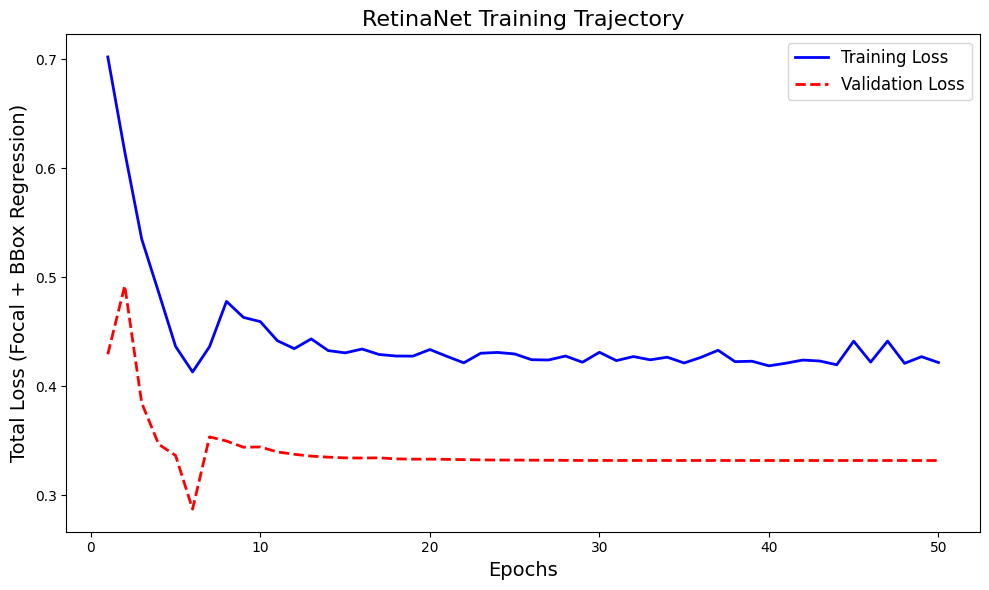

In [24]:
# BLOCK 6: PLOT LOSS TRAJECTORY
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_loss"], "b-", label="Training Loss", linewidth=2)
    plt.plot(epochs, history["val_loss"], "r--", label="Validation Loss", linewidth=2)

    plt.title("RetinaNet Training Trajectory", fontsize=16)
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Total Loss (Focal + BBox Regression)", fontsize=14)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(
        "/home/Joshua/Downloads/leopard_toad_identification/detection/retinanet_loss_plot.png",
        dpi=300,
    )
    plt.show()


plot_training_history(history)

Evaluating RetinaNet on validation set...


/tmp/ipykernel_399440/3160105475.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_roc.legend(loc="lower right", fontsize=10)


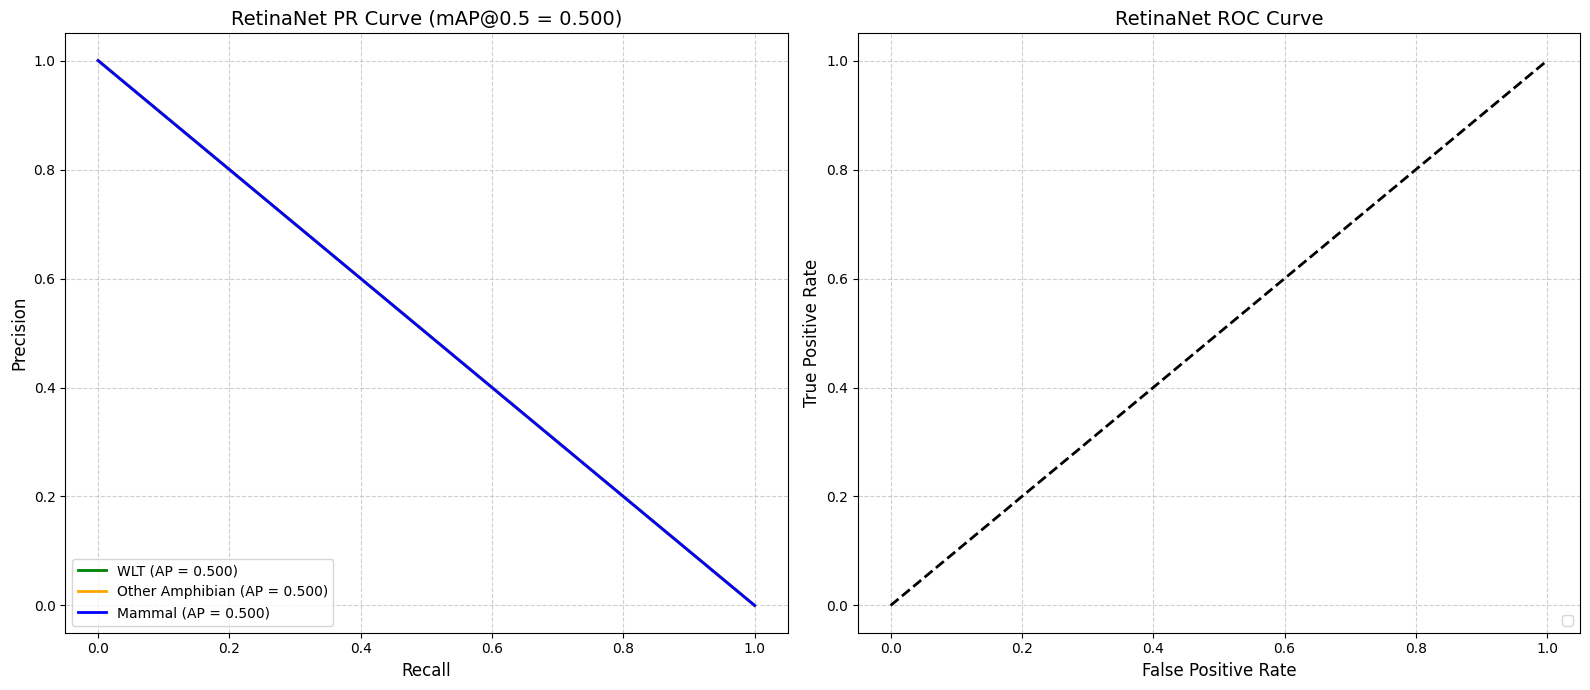

In [25]:
# BLOCK 8: PR & ROC-AUC CURVES (EVALUATION)
import torchvision.ops.boxes as box_ops
from sklearn.metrics import auc, roc_curve


def evaluate_and_plot_curves(model, val_loader, device, iou_threshold=0.5):
    print("Evaluating RetinaNet on validation set...")
    model.eval()

    classes = [1, 2, 3]
    gt_counts = {c: 0 for c in classes}
    predictions_data = {c: [] for c in classes}

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for output, target in zip(outputs, targets):
                gt_boxes = target["boxes"].to(device)
                gt_labels = target["labels"].to(device)

                pred_boxes = output["boxes"].to(device)
                pred_labels = output["labels"].to(device)
                pred_scores = output["scores"].to(device)

                for c in classes:
                    gt_counts[c] += (gt_labels == c).sum().item()

                for c in classes:
                    c_gt_boxes = gt_boxes[gt_labels == c]
                    c_pred_mask = pred_labels == c
                    c_pred_boxes = pred_boxes[c_pred_mask]
                    c_pred_scores = pred_scores[c_pred_mask]

                    sort_idx = torch.argsort(c_pred_scores, descending=True)
                    c_pred_boxes = c_pred_boxes[sort_idx]
                    c_pred_scores = c_pred_scores[sort_idx]

                    matched_gt = set()

                    for i in range(len(c_pred_boxes)):
                        score = c_pred_scores[i].item()
                        is_tp = 0

                        if len(c_gt_boxes) > 0:
                            ious = box_ops.box_iou(
                                c_pred_boxes[i].unsqueeze(0), c_gt_boxes
                            )[0]
                            max_iou, max_idx = ious.max(0)
                            max_idx = max_idx.item()

                            if max_iou >= iou_threshold and max_idx not in matched_gt:
                                is_tp = 1
                                matched_gt.add(max_idx)

                        predictions_data[c].append((score, is_tp))

    fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(16, 7))
    class_names = {1: "WLT", 2: "Other Amphibian", 3: "Mammal"}
    colors = {1: "green", 2: "orange", 3: "blue"}

    mean_ap = 0.0

    for c in classes:
        if gt_counts[c] == 0:
            continue

        data = sorted(predictions_data[c], key=lambda x: x[0], reverse=True)
        scores = [x[0] for x in data]
        tps = [x[1] for x in data]
        fps = [1 - x for x in tps]

        cum_tps = np.cumsum(tps)
        cum_fps = np.cumsum(fps)

        recalls = cum_tps / gt_counts[c]
        precisions = cum_tps / (cum_tps + cum_fps + 1e-16)

        recalls = np.concatenate(([0.0], recalls, [1.0]))
        precisions = np.concatenate(([1.0], precisions, [0.0]))

        ap = auc(recalls, precisions)
        mean_ap += ap

        ax_pr.plot(
            recalls,
            precisions,
            color=colors[c],
            lw=2,
            label=f"{class_names[c]} (AP = {ap:.3f})",
        )

        if sum(fps) > 0:
            fpr, tpr, _ = roc_curve(tps, scores)
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(
                fpr,
                tpr,
                color=colors[c],
                lw=2,
                label=f"{class_names[c]} (AUC = {roc_auc:.3f})",
            )

    ax_pr.set_title(
        f"RetinaNet PR Curve (mAP@0.5 = {mean_ap / len(classes):.3f})", fontsize=14
    )
    ax_pr.set_xlabel("Recall", fontsize=12)
    ax_pr.set_ylabel("Precision", fontsize=12)
    ax_pr.legend(loc="lower left", fontsize=10)
    ax_pr.grid(True, linestyle="--", alpha=0.6)

    ax_roc.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
    ax_roc.set_title("RetinaNet ROC Curve", fontsize=14)
    ax_roc.set_xlabel("False Positive Rate", fontsize=12)
    ax_roc.set_ylabel("True Positive Rate", fontsize=12)
    ax_roc.legend(loc="lower right", fontsize=10)
    ax_roc.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.savefig(
        "/home/Joshua/Downloads/leopard_toad_identification/detection/retinanet_evaluation_curves.png",
        dpi=300,
    )
    plt.show()


evaluate_and_plot_curves(model, val_loader, DEVICE, iou_threshold=0.95)

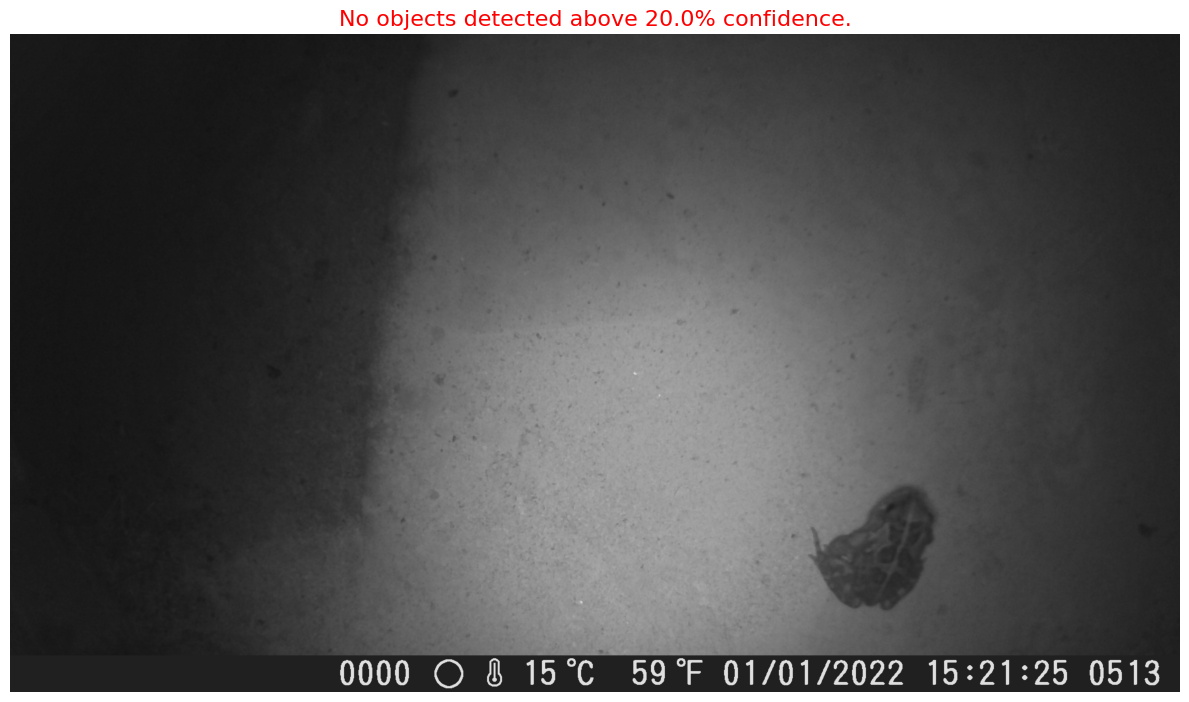

In [26]:
# INFERENCE & VISUALIZATION
WEIGHTS_PATH = "/home/Joshua/Downloads/leopard_toad_identification/detection/weights/best_retinanet.pth"
TEST_IMAGE_PATH = (
    "/srv/shared_leopard_toad/2023/Cameras - AI Data/Observed/Seen/5z-100 (389).JPG"
)
CONF_THRESH = 0.2  # Minimum confidence score to display a box

CLASS_NAMES = {1: "WLT", 2: "Other_Frog", 3: "Mammal"}
COLORS = {1: "#00FF00", 2: "#FFA500", 3: "#00BFFF"}  # Green, Orange, Blue
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 2. Define the Inference Transform (Same as Validation Transform)
# We only scale to 0-1 and convert to tensor. No augmentations here!
inference_transform = A.Compose([A.ToFloat(max_value=255.0), ToTensorV2()])

# 3. Load Model Weights
# (Assumes 'model' is already initialized in your notebook memory from Block 4.
# If not, you must re-run Block 4 to define the architecture first).
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()  # CRITICAL: Switch to evaluation mode!

# 4. Load and Preprocess Image
# Read with OpenCV, convert BGR to RGB
img_array = cv2.imread(TEST_IMAGE_PATH)
img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

# Apply transform
transformed = inference_transform(image=img_array)
img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)  # Add batch dimension

# 5. Run Inference
with torch.no_grad():
    predictions = model(img_tensor)[0]  # Extract the first image's results

# Move results to CPU for matplotlib
boxes = predictions["boxes"].cpu().numpy()
labels = predictions["labels"].cpu().numpy()
scores = predictions["scores"].cpu().numpy()

# 6. Plotting
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img_array)

detections_found = 0

for box, label, score in zip(boxes, labels, scores):
    if score >= CONF_THRESH:
        detections_found += 1
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin

        class_name = CLASS_NAMES.get(label, "Unknown")
        color = COLORS.get(label, "red")

        # Draw Bounding Box
        rect = patches.Rectangle(
            (xmin, ymin), width, height, linewidth=3, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

        # Draw Label Text Background
        label_text = f"{class_name}: {score:.2f}"
        ax.text(
            xmin,
            ymin - 10,
            label_text,
            color="black",
            fontsize=12,
            fontweight="bold",
            bbox=dict(
                facecolor=color, alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"
            ),
        )

if detections_found == 0:
    plt.title(
        f"No objects detected above {CONF_THRESH * 100}% confidence.",
        fontsize=16,
        color="red",
    )
else:
    plt.title(f"Model Detections (Threshold: {CONF_THRESH})", fontsize=16)

plt.axis("off")
plt.tight_layout()
plt.show()